In [62]:
import pandas as pd
import numpy as np
import os   

In [101]:
train_df = pd.read_csv("../data/train_data_with_extracted_features-new.csv")
test_df = pd.read_csv("../data/test_data_with_extracted_features-new.csv")


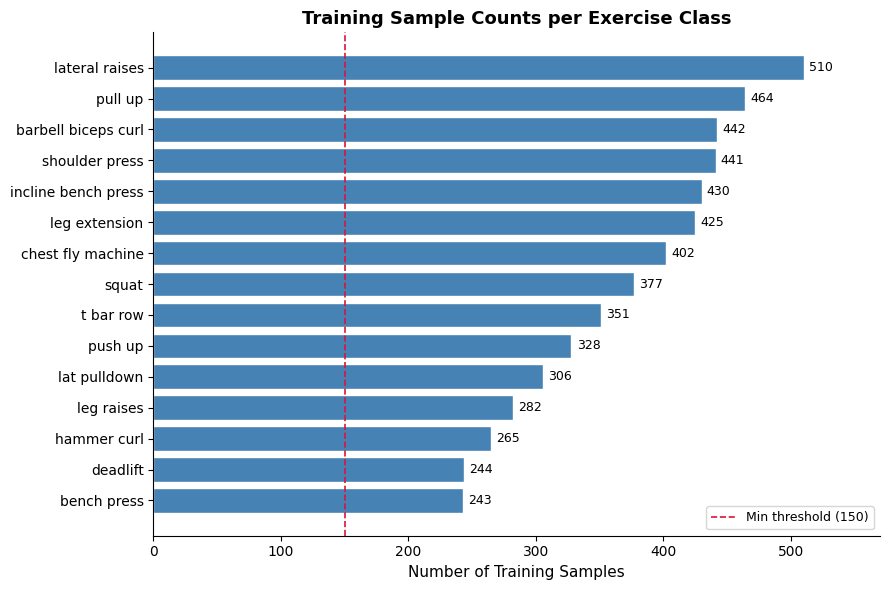

In [102]:
import matplotlib.pyplot as plt

class_counts = train_df['folder_name'].value_counts().sort_values()

fig, ax = plt.subplots(figsize=(9, 6))

bars = ax.barh(class_counts.index, class_counts.values, color='steelblue', edgecolor='white')

# Count labels at end of each bar
for bar, val in zip(bars, class_counts.values):
    ax.text(val + 4, bar.get_y() + bar.get_height() / 2,
            str(val), va='center', fontsize=9)

ax.axvline(x=150, color='crimson', linestyle='--', linewidth=1.2, label='Min threshold (150)')
ax.set_xlabel('Number of Training Samples', fontsize=11)
ax.set_title('Training Sample Counts per Exercise Class', fontsize=13, fontweight='bold')
ax.set_xlim(0, class_counts.max() + 60)
ax.legend(fontsize=9)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.savefig('class_distribution.png', dpi=150)
plt.show()


In [103]:
train_df = train_df[train_df["body_angles"] != "Not Found"]
train_df = train_df[train_df["shoulder_angles"] != "Not Found"]
train_df = train_df[train_df["elbow_angles"] != "Not Found"]
train_df = train_df[train_df["hip_angles"] != "Not Found"]
train_df = train_df[train_df["knee_angles"] != "Not Found"]



In [104]:
train_df['folder_name'].value_counts()

folder_name
pull up                274
t bar row              225
deadlift               224
leg raises             199
chest fly machine      187
leg extension          184
squat                  173
barbell biceps curl    146
hammer curl            138
push up                121
shoulder press         108
lateral raises         104
incline bench press     93
lat pulldown            87
bench press             55
Name: count, dtype: int64

In [105]:
class_counts = train_df['folder_name'].value_counts()
threshold = 150
valid_classes = class_counts[class_counts >= threshold].index

# Filter the DataFrame to keep only valid classes
train_df = train_df[train_df['folder_name'].isin(valid_classes)]

In [106]:
train_df['folder_name'].value_counts()

folder_name
pull up              274
t bar row            225
deadlift             224
leg raises           199
chest fly machine    187
leg extension        184
squat                173
Name: count, dtype: int64

In [107]:
test_df = test_df[test_df["body_angles"] != "Not Found"]
test_df = test_df[test_df["shoulder_angles"] != "Not Found"]
test_df = test_df[test_df["knee_angles"] != "Not Found"]
test_df = test_df[test_df["elbow_angles"] != "Not Found"]
test_df = test_df[test_df["hip_angles"] != "Not Found"]

test_df['folder_name'].value_counts()

folder_name
pull up                30
leg extension          27
deadlift               27
leg raises             23
chest fly machine      22
squat                  19
t bar row              17
push up                15
hammer curl            14
barbell biceps curl    13
incline bench press    11
lat pulldown           11
shoulder press          6
bench press             5
lateral raises          3
Name: count, dtype: int64

In [108]:
selected_exercises = ["pull up", "chest fly machine",  "t bar row", "squat", "leg extension", "leg raises", "deadlift"]

test_df = test_df[test_df["folder_name"].isin(selected_exercises)]

test_df['folder_name'].value_counts()

folder_name
pull up              30
leg extension        27
deadlift             27
leg raises           23
chest fly machine    22
squat                19
t bar row            17
Name: count, dtype: int64

In [109]:
from sklearn.model_selection import train_test_split

valid, test = train_test_split(test_df, test_size=0.2, random_state=42)

In [110]:
test['folder_name'].value_counts()

folder_name
pull up              8
leg raises           5
deadlift             5
chest fly machine    5
squat                4
leg extension        4
t bar row            2
Name: count, dtype: int64

In [111]:
valid['folder_name'].value_counts()

folder_name
leg extension        23
pull up              22
deadlift             22
leg raises           18
chest fly machine    17
t bar row            15
squat                15
Name: count, dtype: int64

In [112]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

train_df["folder_name"] = le.fit_transform(train_df["folder_name"])
valid["folder_name"] = le.transform(valid["folder_name"])
test["folder_name"] = le.transform(test["folder_name"])

In [113]:
train_df = pd.get_dummies(train_df, columns=["front_facing_boolean"])
valid = pd.get_dummies(valid, columns=["front_facing_boolean"])

X_train = train_df.drop(['image_path', 'folder_name'], axis=1)
y_train = train_df['folder_name']

X_test = valid.drop(['image_path', 'folder_name'], axis=1)
y_test = valid['folder_name']

In [114]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [115]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

clf = RandomForestClassifier(n_estimators=100, random_state=42)
clf.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [116]:
y_pred = clf.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.9090909090909091


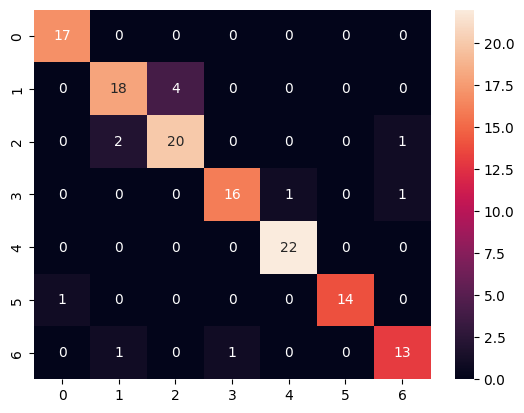

In [117]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt="d")
plt.show()

In [118]:
mapping = dict(zip(le.classes_, le.transform(le.classes_)))
print(mapping)

{'chest fly machine': np.int64(0), 'deadlift': np.int64(1), 'leg extension': np.int64(2), 'leg raises': np.int64(3), 'pull up': np.int64(4), 'squat': np.int64(5), 't bar row': np.int64(6)}


In [119]:
importances = clf.feature_importances_
feature_names = ['shoulder_angles', 'elbow_angles',
       'hip_angles', 'knee_angles', 'body_angles',
       'front_facing_boolean_False', 'front_facing_boolean_True']

sorted_indices = importances.argsort()[::-1]
for i in sorted_indices:
    print(f"{feature_names[i]}: {importances[i]:.4f}")

shoulder_angles: 0.2762
elbow_angles: 0.2585
body_angles: 0.1657
hip_angles: 0.1446
knee_angles: 0.1380
front_facing_boolean_True: 0.0090
front_facing_boolean_False: 0.0080


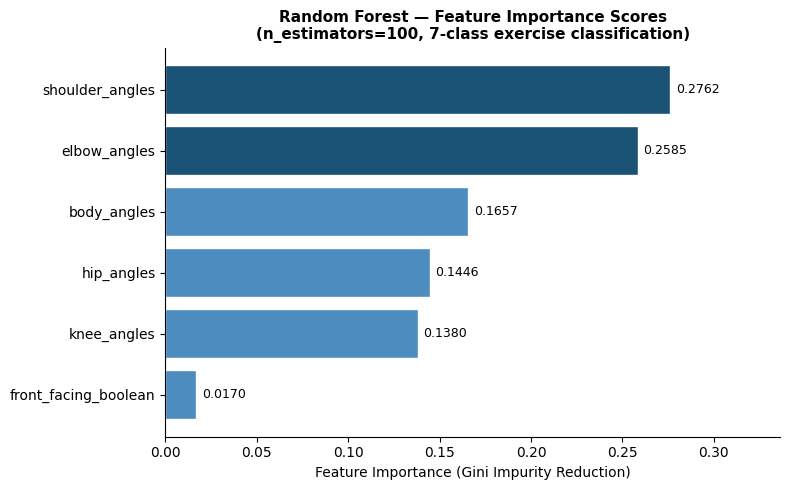

In [120]:
import matplotlib.pyplot as plt
import numpy as np

# Raw importances from the 7-feature RF (with OHE front_facing split)
raw_importances = clf.feature_importances_
raw_names = [
    'shoulder_angles', 'elbow_angles', 'hip_angles',
    'knee_angles', 'body_angles',
    'front_facing_boolean_False', 'front_facing_boolean_True'
]

# Combine the two boolean columns into one
imp_dict = dict(zip(raw_names, raw_importances))
feature_names = [
    'shoulder_angles', 'elbow_angles', 'hip_angles',
    'knee_angles', 'body_angles', 'front_facing_boolean'
]
importances = [
    imp_dict['shoulder_angles'],
    imp_dict['elbow_angles'],
    imp_dict['hip_angles'],
    imp_dict['knee_angles'],
    imp_dict['body_angles'],
    imp_dict['front_facing_boolean_False'] + imp_dict['front_facing_boolean_True']
]

# Sort ascending so highest bar is at top
sorted_idx = np.argsort(importances)
sorted_names = [feature_names[i] for i in sorted_idx]
sorted_imp   = [importances[i]   for i in sorted_idx]

# Colour: highlight the two most important features
colours = ['#4c8cbf' if v < 0.20 else '#1a5276' for v in sorted_imp]

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.barh(sorted_names, sorted_imp, color=colours, edgecolor='white')

# Value labels
for bar, val in zip(bars, sorted_imp):
    ax.text(val + 0.003, bar.get_y() + bar.get_height() / 2,
            f'{val:.4f}', va='center', fontsize=9)

ax.set_xlabel('Feature Importance (Gini Impurity Reduction)', fontsize=10)
ax.set_title('Random Forest — Feature Importance Scores\n(n_estimators=100, 7-class exercise classification)',
             fontsize=11, fontweight='bold')
ax.set_xlim(0, max(sorted_imp) + 0.06)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150)
plt.show()


In [47]:
X_train = train_df.drop(['image_path', 'folder_name','front_facing_boolean_True','front_facing_boolean_False'], axis=1)
y_train = train_df['folder_name']

In [48]:
X_test = valid.drop(['image_path', 'folder_name','front_facing_boolean_True','front_facing_boolean_False'], axis=1)
y_test = valid['folder_name']

In [49]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

clf = RandomForestClassifier(n_estimators=100, random_state=42)
clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.8787878787878788


In [50]:
from sklearn.model_selection import GridSearchCV

rf_grid = RandomForestClassifier()
gr_space = {
    'max_depth': [3,5,7,10],
    'n_estimators': [50, 100, 200, 250],
    'max_features': [2, 3, 4 , 5],
    'min_samples_leaf': [1, 2, 4]
}

grid = GridSearchCV(rf_grid, gr_space, cv = 3, scoring='accuracy', verbose = 3)
model_grid = grid.fit(X_train, y_train)

print('Best hyperparameters are '+str(model_grid.best_params_))
print('Best score is: ' + str(model_grid.best_score_))

Fitting 3 folds for each of 192 candidates, totalling 576 fits
[CV 1/3] END max_depth=3, max_features=2, min_samples_leaf=1, n_estimators=50;, score=0.740 total time=   0.0s
[CV 2/3] END max_depth=3, max_features=2, min_samples_leaf=1, n_estimators=50;, score=0.701 total time=   0.0s
[CV 3/3] END max_depth=3, max_features=2, min_samples_leaf=1, n_estimators=50;, score=0.629 total time=   0.0s
[CV 1/3] END max_depth=3, max_features=2, min_samples_leaf=1, n_estimators=100;, score=0.740 total time=   0.0s
[CV 2/3] END max_depth=3, max_features=2, min_samples_leaf=1, n_estimators=100;, score=0.726 total time=   0.0s
[CV 3/3] END max_depth=3, max_features=2, min_samples_leaf=1, n_estimators=100;, score=0.672 total time=   0.0s
[CV 1/3] END max_depth=3, max_features=2, min_samples_leaf=1, n_estimators=200;, score=0.740 total time=   0.1s
[CV 2/3] END max_depth=3, max_features=2, min_samples_leaf=1, n_estimators=200;, score=0.710 total time=   0.2s
[CV 3/3] END max_depth=3, max_features=2, mi

In [51]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(objective="multi:softmax", num_class=len(le.classes_), eval_metric="mlogloss", random_state=42)
xgb_model.fit(X_train, y_train)
y_pred_xgb = xgb_model.predict(X_test)

print("XGBoost Accuracy:", accuracy_score(y_test, y_pred_xgb))

XGBoost Accuracy: 0.8863636363636364


In [52]:
from sklearn.neighbors import KNeighborsClassifier

knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train, y_train)

y_pred_knn = knn_model.predict(X_test)

print("KNN Accuracy:", accuracy_score(y_test, y_pred_knn))

KNN Accuracy: 0.8712121212121212


In [53]:
from sklearn.svm import SVC

svm_model = SVC(kernel="rbf", C=1.0, decision_function_shape="ovo", random_state=42)
svm_model.fit(X_train, y_train)

y_pred_svm = svm_model.predict(X_test)

print("SVM Accuracy:", accuracy_score(y_test, y_pred_svm))

SVM Accuracy: 0.7651515151515151


In [56]:
from sklearn.linear_model import LogisticRegression

log_reg_model = LogisticRegression(solver="lbfgs", max_iter=500)
log_reg_model.fit(X_train, y_train)

y_pred_logreg = log_reg_model.predict(X_test)

print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_logreg))

Logistic Regression Accuracy: 0.6893939393939394


In [57]:
model_results = {
    "XGBoost": accuracy_score(y_test, y_pred_xgb),
    "SVM": accuracy_score(y_test, y_pred_svm),
    "KNN": accuracy_score(y_test, y_pred_knn),
    "Logistic Regression": accuracy_score(y_test, y_pred_logreg),
}

print(model_results)


{'XGBoost': 0.8863636363636364, 'SVM': 0.7651515151515151, 'KNN': 0.8712121212121212, 'Logistic Regression': 0.6893939393939394}


In [58]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.utils import to_categorical

In [59]:
y_onehot_train = to_categorical(y_train, num_classes=len(le.classes_))
y_onehot_test = to_categorical(y_test, num_classes=len(le.classes_))

In [60]:
# Define model
model = Sequential([
    Dense(128, activation="relu", input_shape=(X_train.shape[1],)),
    Dropout(0.3),  # Prevent overfitting
    Dense(64, activation="relu"),
    Dropout(0.3),
    Dense(len(le.classes_), activation="softmax")  # Softmax for multiclass classification
])

# Compile the model
model.compile(optimizer="adam", loss="categorical_crossentropy", metrics=["accuracy"])

# Model summary
model.summary()

c:\Users\user\Desktop\Learning\MSc\Research\MotionGuard\venv\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │           768 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 7)              │           455 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,479 (37.03 KB)

 Trainable params: 9,479 (37.03 KB)

 Non-trainable params: 0 (0.00 B)

In [61]:
history = model.fit(X_train, y_onehot_train, validation_data=(X_test, y_onehot_test), epochs=50, batch_size=32, verbose=1)

Epoch 1/50
46/46 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.3786 - loss: 1.6856 - val_accuracy: 0.5379 - val_loss: 1.3621
Epoch 2/50
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5061 - loss: 1.3047 - val_accuracy: 0.6364 - val_loss: 1.0178
Epoch 3/50
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5518 - loss: 1.1228 - val_accuracy: 0.7348 - val_loss: 0.8798
Epoch 4/50
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5805 - loss: 1.0387 - val_accuracy: 0.6970 - val_loss: 0.8200
Epoch 5/50
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6112 - loss: 0.9962 - val_accuracy: 0.7348 - val_loss: 0.7603
Epoch 6/50
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6276 - loss: 0.9731 - val_accuracy: 0.6818 - val_loss: 0.7462
Epoch 7/50
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6132 - loss: 0.9486 - val_accuracy: 0.7121 - val_loss: 0.7216
Epoch 8/50
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6364 - loss: 0.9307 - val_accuracy: 0.7273 - val_loss:

In [63]:
# Predict class probabilities
y_pred_probs = model.predict(X_test)

# Convert probabilities to class labels
y_pred_classes = np.argmax(y_pred_probs, axis=1)
y_test_classes = np.argmax(y_onehot_test, axis=1)

# Print accuracy
print("Neural Network Accuracy:", accuracy_score(y_test_classes, y_pred_classes))

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step 
Neural Network Accuracy: 0.803030303030303


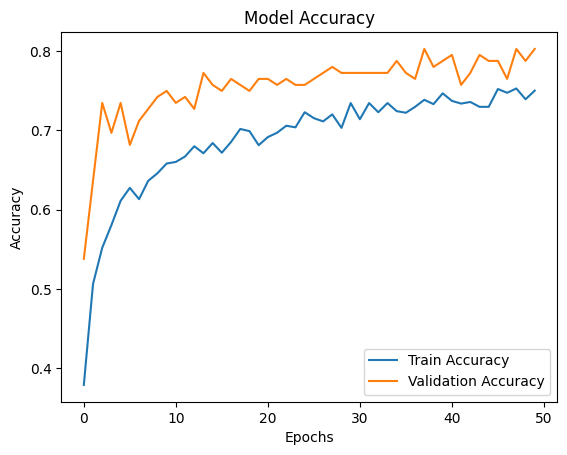

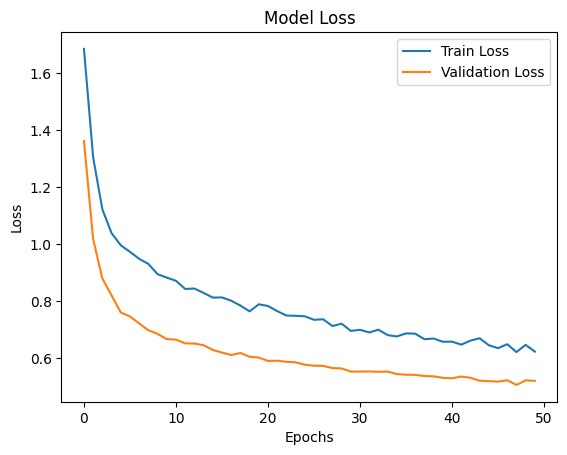

In [64]:
import matplotlib.pyplot as plt

# Plot training & validation accuracy
plt.plot(history.history["accuracy"], label="Train Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.title("Model Accuracy")
plt.show()

# Plot training & validation loss
plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.title("Model Loss")
plt.show()

In [86]:
import pandas as pd
import numpy as np

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import classification_report, accuracy_score
from xgboost import XGBClassifier

In [87]:
print("Train shape:", train_df.shape)
print("Val shape:", valid.shape)
print("Test shape:", test.shape)

Train shape: (1466, 8)
Val shape: (132, 8)
Test shape: (33, 8)


In [88]:
for df in [train_df, valid, test]:
    df["folder_name"] = df["folder_name"].str.strip()

In [89]:
# Features to use
feature_columns = [
    "shoulder_angles",
    "elbow_angles",
    "hip_angles",
    "knee_angles",
    "body_angles",
    "front_facing_boolean"
]

for df in [train_df, valid, test]:
    df["front_facing_boolean"] = df["front_facing_boolean"].astype(str).str.strip().str.lower()
    df["front_facing_boolean"] = df["front_facing_boolean"].map({"true": 1, "false": 0})

# Extract features
X_train = train_df[feature_columns].values
X_val = valid[feature_columns].values
X_test = test[feature_columns].values

In [90]:
le = LabelEncoder()

y_train = le.fit_transform(train_df["folder_name"])
y_val = le.transform(valid["folder_name"])
y_test = le.transform(test["folder_name"])

class_names = le.classes_
num_classes = len(class_names)

print("Classes:", class_names)
print("Number of classes:", num_classes)

Classes: ['chest fly machine' 'deadlift' 'leg extension' 'leg raises' 'pull up'
 'squat' 't bar row']
Number of classes: 7


In [91]:
scaler = StandardScaler()

X_train[:, :-1] = scaler.fit_transform(X_train[:, :-1])  # exclude binary column
X_val[:, :-1] = scaler.transform(X_val[:, :-1])
X_test[:, :-1] = scaler.transform(X_test[:, :-1])

In [92]:
models = {}

for cls in range(num_classes):
    print(f"\nTraining classifier for: {class_names[cls]}")

    # Create binary labels
    y_train_bin = (y_train == cls).astype(int)
    y_val_bin = (y_val == cls).astype(int)

    # Handle imbalance
    pos = np.sum(y_train_bin == 1)
    neg = np.sum(y_train_bin == 0)
    scale_pos_weight = neg / pos if pos > 0 else 1

    model = XGBClassifier(
        eval_metric="logloss",
        scale_pos_weight=scale_pos_weight,
        use_label_encoder=False,
        random_state=42
    )

    model.fit(X_train, y_train_bin)

    # Validate
    val_pred = model.predict(X_val)
    acc = accuracy_score(y_val_bin, val_pred)

    print(f"Validation Accuracy: {acc:.4f}")

    models[cls] = model


Training classifier for: chest fly machine
Validation Accuracy: 0.9848

Training classifier for: deadlift
Validation Accuracy: 0.9318

Training classifier for: leg extension


c:\Users\user\Desktop\Learning\MSc\Research\MotionGuard\venv\Lib\site-packages\xgboost\training.py:200: UserWarning: [12:13:03] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
c:\Users\user\Desktop\Learning\MSc\Research\MotionGuard\venv\Lib\site-packages\xgboost\training.py:200: UserWarning: [12:13:03] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
c:\Users\user\Desktop\Learning\MSc\Research\MotionGuard\venv\Lib\site-packages\xgboost\training.py:200: UserWarning: [12:13:03] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
c:\Users\user\Desktop\Learning\MSc\Research\MotionGuard\venv\Lib\site-packages\xgboost\training.py:200: UserWarning: [12:

Validation Accuracy: 0.9545

Training classifier for: leg raises
Validation Accuracy: 0.9848

Training classifier for: pull up
Validation Accuracy: 0.9924

Training classifier for: squat
Validation Accuracy: 0.9848

Training classifier for: t bar row
Validation Accuracy: 0.9773


c:\Users\user\Desktop\Learning\MSc\Research\MotionGuard\venv\Lib\site-packages\xgboost\training.py:200: UserWarning: [12:13:03] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
c:\Users\user\Desktop\Learning\MSc\Research\MotionGuard\venv\Lib\site-packages\xgboost\training.py:200: UserWarning: [12:13:03] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


In [93]:
def predict_ovr(models, X):
    probs = []

    for cls, model in models.items():
        prob = model.predict_proba(X)[:, 1]  # probability of class=1
        probs.append(prob)

    probs = np.array(probs).T  # shape: (n_samples, num_classes)

    return np.argmax(probs, axis=1)

In [94]:
# Get predictions
y_pred = predict_ovr(models, X_test)

# Convert to labels
y_pred_labels = le.inverse_transform(y_pred)
y_true_labels = le.inverse_transform(y_test)

# Evaluation
print("Final Multiclass Accuracy:", accuracy_score(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_true_labels, y_pred_labels))

Final Multiclass Accuracy: 0.8484848484848485

Classification Report:
                   precision    recall  f1-score   support

chest fly machine       1.00      1.00      1.00         5
         deadlift       0.80      0.80      0.80         5
    leg extension       0.80      1.00      0.89         4
       leg raises       1.00      0.40      0.57         5
          pull up       0.73      1.00      0.84         8
            squat       1.00      1.00      1.00         4
        t bar row       1.00      0.50      0.67         2

         accuracy                           0.85        33
        macro avg       0.90      0.81      0.82        33
     weighted avg       0.88      0.85      0.83        33



In [95]:
import joblib
import os

save_dir = "../models"
os.makedirs(save_dir, exist_ok=True)

# Save scaler and label encoder
joblib.dump(scaler, f"{save_dir}/scaler.pkl")
joblib.dump(le, f"{save_dir}/label_encoder.pkl")

# Save each OvR binary classifier individually
for cls_idx, model in models.items():
    model.save_model(f"{save_dir}/xgb_ovr_{cls_idx}_{class_names[cls_idx].replace(' ', '_')}.json")

print("Saved:")
print(f"  {save_dir}/scaler.pkl")
print(f"  {save_dir}/label_encoder.pkl")
for cls_idx in models:
    print(f"  {save_dir}/xgb_ovr_{cls_idx}_{class_names[cls_idx].replace(' ', '_')}.json")


Saved:
  ../models/scaler.pkl
  ../models/label_encoder.pkl
  ../models/xgb_ovr_0_chest_fly_machine.json
  ../models/xgb_ovr_1_deadlift.json
  ../models/xgb_ovr_2_leg_extension.json
  ../models/xgb_ovr_3_leg_raises.json
  ../models/xgb_ovr_4_pull_up.json
  ../models/xgb_ovr_5_squat.json
  ../models/xgb_ovr_6_t_bar_row.json


In [96]:
import joblib
import numpy as np
from xgboost import XGBClassifier

save_dir = "../models"

scaler     = joblib.load(f"{save_dir}/scaler.pkl")
le         = joblib.load(f"{save_dir}/label_encoder.pkl")
class_names = le.classes_

loaded_models = {}
for cls_idx, cls_name in enumerate(class_names):
    m = XGBClassifier()
    m.load_model(f"{save_dir}/xgb_ovr_{cls_idx}_{cls_name.replace(' ', '_')}.json")
    loaded_models[cls_idx] = m

def predict(feature_row):
    """
    feature_row: array-like of shape (6,)
      [shoulder_angles, elbow_angles, hip_angles, knee_angles,
       body_angles, front_facing_boolean (0 or 1)]
    Returns predicted class name.
    """
    X = np.array(feature_row).reshape(1, -1)
    X[:, :-1] = scaler.transform(X[:, :-1])   # scale all but binary column
    probs = np.array([loaded_models[i].predict_proba(X)[0, 1]
                      for i in range(len(loaded_models))])
    return le.inverse_transform([np.argmax(probs)])[0]

# Quick smoke test
sample = [136.5, 124.7, 177.9, 174.9, 0.34, 1]
print("Predicted exercise:", predict(sample))


Predicted exercise: pull up
